In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Dataset generation

In [2]:
df=pd.read_csv(r"C:\Users\vithu\OneDrive\Desktop\IISERB'26\Student behaviour modelling\master_NT_Mood_Intervention.csv")
df_clean=df.dropna(subset=["Context"]).copy()
df_clean["NT_post_Timestamp"]=pd.to_datetime(df_clean['NT_post_Timestamp'])
df_clean["NT_post_Timestamp"].dtype

datetime64[ns, UTC]

In [3]:
df_clean['NT_post_Timestamp'] = df_clean['NT_post_Timestamp'].dt.tz_localize(None)

df_filtered=df_clean[df_clean['NT_post_Timestamp'].between('2025-03-30','2025-04-05')]

In [4]:
ong_activity=df_filtered["Context"].unique()
surr=df_filtered["Social Context"].unique()
p_id=df_filtered['Participant_Id'].unique()
interventions = df_filtered["Intervention"].unique()

In [5]:
# We'll pick first seven days and randomly pick 30 ppl to create a activity frequency chart

rng=np.random.default_rng()
ppl_list=rng.choice(p_id,size=30,replace=False)

df_filtered_select= df_filtered[df_filtered['Participant_Id'].isin(ppl_list)]

### Getting prior for Activity

In [6]:
context_counts=df_filtered_select["Context"].value_counts()

print(ong_activity)
freq=[0]*len(ong_activity)
for k,v in context_counts.items():
    for i in range(len(ong_activity)):
        if ong_activity[i]==k:
            freq[i]=v/(7*30) # 7 days and 30 people were chosen

print(freq)

['Relaxing' 'Eating' 'Attending Lecture' 'Studying' 'Walking' 'Standing'
 'Exercise' 'Running' 'E-Rick/Auto' 'Cycling']
[1.8095238095238095, 0.44285714285714284, 0.7380952380952381, 1.3, 0.8857142857142857, 0.48095238095238096, 0.12380952380952381, 0.0380952380952381, 0.047619047619047616, 0.009523809523809525]


## Getting prior for Social context

In [7]:
social_context_counts=df_filtered_select["Social Context"].value_counts()

print(surr)
soc_freq=[0]*len(surr)
for k,v in social_context_counts.items():
    for i in range(len(surr)):
        if surr[i]==k:
            soc_freq[i]=v/(7*30) # 7 days and 30 people were chosen

print(soc_freq)

['Alone' 'With Someone (Not Engaged in Conversation)'
 'With Someone (Engaged in Conversation)']
[3.361904761904762, 0.9857142857142858, 1.5285714285714285]


In [8]:
num_people = 100
days_per_person = 14 
activities_per_day = 14

total_records = num_people * days_per_person * activities_per_day

# --- 2. Normalize BOTH Priors ---
# Ensure both arrays sum perfectly to 1.0 to prevent NumPy errors
act_priors = np.array(freq)
act_priors = act_priors / act_priors.sum()

soc_priors = np.array(soc_freq)
soc_priors = soc_priors / soc_priors.sum()

# --- 3. Generate the Data ---
rng = np.random.default_rng()

# Generate Activities using the activity priors
synthetic_activities = rng.choice(ong_activity, size=total_records, p=act_priors)

# Generate Social Contexts using the new social priors
synthetic_social = rng.choice(surr, size=total_records, p=soc_priors)

# Create Participant IDs, Days, and Slots (Same structure as before)
p_ids = [f"Syn_{str(i).zfill(3)}" for i in range(1, num_people + 1)]
synthetic_ids = np.repeat(p_ids, days_per_person * activities_per_day)

single_person_days = np.repeat(np.arange(1, days_per_person + 1), activities_per_day)
synthetic_days = np.tile(single_person_days, num_people)

synthetic_slots = np.tile(np.arange(1, activities_per_day + 1), num_people * days_per_person)

# --- 4. Build the Final DataFrame ---
synthetic_df = pd.DataFrame({
    'Participant_Id': synthetic_ids,
    'Day': synthetic_days,
    'Activity_Slot': synthetic_slots,
    'Context': synthetic_activities,
    'Social_Context': synthetic_social
})

# Verify the output
print(f"Total synthetic rows created: {len(synthetic_df)}\n")
print(synthetic_df.head(15))

Total synthetic rows created: 19600

   Participant_Id  Day  Activity_Slot            Context  \
0         Syn_001    1              1           Exercise   
1         Syn_001    1              2           Standing   
2         Syn_001    1              3            Running   
3         Syn_001    1              4           Studying   
4         Syn_001    1              5  Attending Lecture   
5         Syn_001    1              6           Studying   
6         Syn_001    1              7           Relaxing   
7         Syn_001    1              8            Walking   
8         Syn_001    1              9             Eating   
9         Syn_001    1             10           Studying   
10        Syn_001    1             11           Standing   
11        Syn_001    1             12           Relaxing   
12        Syn_001    1             13           Studying   
13        Syn_001    1             14           Relaxing   
14        Syn_001    2              1  Attending Lecture   

  

In [9]:
# 1. Define the 16x10 matrix directly from the provided table.
# Rows = 16 Interventions,Columns = 10 Activities
priors_16x10 = np.array([
    [0.842,0.842,0.947,0.526,0.368,0.789,0.474,0.842,0.158,0.972],# Breathing Exercise
    [0.211,0.579,0.972,0.972,0.368,0.947,0.316,0.579,0.895,0.972],# Calling loved ones
    [0.526,0.789,0.972,0.789,0.474,0.789,0.421,0.895,0.526,0.972],# Close your eyes
    [0.895,0.972,0.972,0.895,0.263,0.895,0.316,0.920,0.421,0.972],# Neck Rolls
    [0.158,0.000,0.972,0.632,0.000,0.474,0.000,0.842,0.972,0.789],# Eating something
    [0.053,0.579,0.737,0.000,0.000,0.789,0.368,0.895,0.105,0.789],# Go for a walk
    [0.368,0.000,0.789,0.158,0.000,0.053,0.053,0.632,0.053,0.421],# Journal Writing
    [0.211,0.972,0.972,0.947,0.895,0.972,0.867,0.789,0.842,0.972],# Listening to Music
    [0.684,0.421,0.947,0.474,0.211,0.368,0.211,0.789,0.368,0.842],# List of positive things
    [0.842,0.947,0.972,0.972,0.842,0.972,0.842,0.895,0.947,0.972],# Observe surroundings
    [0.263,0.105,0.842,0.474,0.000,0.263,0.053,0.368,0.263,0.737],# Play mobile game
    [0.421,0.316,0.947,0.842,0.158,0.684,0.158,0.526,0.632,0.895],# Old memories gallery
    [0.368,0.947,0.972,0.158,0.053,0.737,0.368,0.895,0.105,0.947],# Stretching
    [0.158,0.053,0.972,0.842,0.211,0.789,0.000,0.368,0.842,0.842],# Watching funny videos
    [0.158,0.579,0.842,0.684,0.211,0.579,0.105,0.526,0.632,0.789],# Motivational video
    [0.632,0.211,0.895,0.368,0.000,0.158,0.000,0.789,0.158,0.684]  # Writing Down a Worry
])

# 2. Transpose the matrix so it becomes (10 Activities,16 Interventions)
priors_10x16 = priors_16x10.T

# 3. Set the confidence scale (C = alpha + beta)
C = 20.0 

# 4. Calculate the base 2D arrays for alpha and beta (Shape: 10,16)
base_alpha = priors_10x16 * C
base_beta = (1 - priors_10x16) * C

# 5. Broadcast the 2D arrays across all 100 people to create the final 3D tensors
# Shape becomes: (100,10,16)
alpha_tensor = np.broadcast_to(base_alpha,(100,10,16)).copy()
beta_tensor = np.broadcast_to(base_beta,(100,10,16)).copy()

# --- Verification ---
print(f"Final alpha_tensor shape: {alpha_tensor.shape}")
print(f"Final beta_tensor shape:  {beta_tensor.shape}")

print(f"\nPrior for Lecture + Music: {priors_10x16[0,8]}")
print(f"Alpha value: {alpha_tensor[5,0,8]:.2f}")
print(f"Beta value:  {beta_tensor[5,0,8]:.2f}")
print(f"Calculated Prior from alpha and beta: {alpha_tensor[5,0,8] / (alpha_tensor[5,0,8] + beta_tensor[5,0,8]):.3f}")

Final alpha_tensor shape: (100, 10, 16)
Final beta_tensor shape:  (100, 10, 16)

Prior for Lecture + Music: 0.684
Alpha value: 13.68
Beta value:  6.32
Calculated Prior from alpha and beta: 0.684


In [11]:
social_modifiers = np.ones((3, 1, 16))

# =======================================================
# SURROUNDING 0: ALONE
# Interventions requiring privacy or introspection get a moderate boost.
# No artificial penalties needed here; base preferences dictate the rest.
# =======================================================
social_modifiers[0, 0, 7] = 1.1  # Listen to music
social_modifiers[0, 0, 1] = 1.1  # Call a loved one
social_modifiers[0, 0, 15] = 1.1 # Writing Down a Worry and Putting It Aside
social_modifiers[0, 0, 8] = 1.1  # Make a list of positive things inside you
social_modifiers[0, 0, 0] = 1.1  # Breathing Exercise


# =======================================================
# SURROUNDING 1: WITH SOMEONE (IN CONVO)
# Disincentivizes distraction, but leaves room for outliers.
# Boosts shared activities smoothly.
# =======================================================
# Soft penalties instead of hard bans
social_modifiers[1, 0, 7] = 0.8  # Listen to music
social_modifiers[1, 0, 1] = 0.8  # Call a loved one
social_modifiers[1, 0, 2] = 0.8  # Close eyes and hear ambient sounds
social_modifiers[1, 0, 6] = 0.8  # Journal Writing
social_modifiers[1, 0, 13] = 0.8 # Watching funny videos
social_modifiers[1, 0, 14] = 0.8 # Watching motivational videos
social_modifiers[1, 0, 10] = 0.8 # Play mobile game

# Moderate boosts for collaborative actions
social_modifiers[1, 0, 5] = 1.1 # Go for a small walk 
social_modifiers[1, 0, 9] = 1.1  # Observe your surroundings 
social_modifiers[1, 0, 4] = 1.1  # Eating something you like 


# =======================================================
# SURROUNDING 2: WITH SOMEONE (NOT IN CONVO)
# Slight preference for silent, private activities.
# =======================================================
social_modifiers[2, 0, 11] = 1.1 # Scroll through old memories
social_modifiers[2, 0, 10] = 1.1 # Play mobile game 
social_modifiers[2, 0, 3] = 0.8  # Doing Simple Neck Rolls

# Apply the modifiers and ensure probabilities stay in valid Beta bounds
base_3d_priors = np.clip(priors_10x16 * social_modifiers, 0.01, 0.99)

# Generate the population
diversity_factor = 5
pop_alpha_4d = base_3d_priors * diversity_factor
pop_beta_4d = (1 - base_3d_priors) * diversity_factor

pop_alpha_4d = np.broadcast_to(pop_alpha_4d, (100, 3, 10, 16))
pop_beta_4d = np.broadcast_to(pop_beta_4d, (100, 3, 10, 16))

# The Ground Truth Environment
receptiveness_tensor_4d = np.random.beta(pop_alpha_4d, pop_beta_4d)

print(f"Shape of 4D Oracle: {receptiveness_tensor_4d.shape}")

Shape of 4D Oracle: (100, 3, 10, 16)


# Participant Level

## 10 Mab for each participant

In [12]:
class BernoulliThompsonSampling:
    def __init__(self,n_arms,alpha_tensor,beta_tensor):
        self.n_arms=n_arms
        epsilon=1e-5
        self.alpha=np.clip(alpha_tensor,epsilon,np.inf).astype(float)
        self.beta=np.clip(beta_tensor,epsilon,np.inf).astype(float)

    def arm_to_pull(self,person,activity):
        samples=np.random.beta(self.alpha[person,activity],self.beta[person,activity])
        return np.argmax(samples)

    def update(self,person,activity,arm,reward):
        if reward==1:
            self.alpha[person,activity,arm]+=1
        elif reward==0.5:
            self.beta[person,activity,arm]+=0.5
            self.alpha[person,activity,arm]+=0.5
        elif reward==0:
            self.beta[person,activity,arm]+=1

In [13]:
# --- 1. Create String-to-Index Mappings ---
# This allows us to convert the DataFrame text (e.g., 'Syn_001') into the correct tensor index (e.g., 0)
person_to_idx = {person: idx for idx, person in enumerate(p_ids)}
act_to_idx = {act: idx for idx, act in enumerate(ong_activity)}
surr_to_idx = {s: idx for idx, s in enumerate(surr)}

# --- 2. Initialize Tracking Variables ---
cumulative_regret_bts = []
current_regret_bts = 0
optimal_action_count_bts = 0
optimal_action_rate_bts = []
total_reward_bts = 0 

# Make sure tensors are float and initialize the agent
alpha_tensor = alpha_tensor.astype(float)
beta_tensor = beta_tensor.astype(float)
agent = BernoulliThompsonSampling(n_arms=16, alpha_tensor=alpha_tensor, beta_tensor=beta_tensor)

print("Starting DataFrame Training Loop...")
print("-" * 60)

# --- 3. The New Training Loop ---
# itertuples() yields a named tuple for each row, which is extremely fast
for step, row in enumerate(synthetic_df.itertuples()):
    
    # A. Get Context from the current DataFrame row
    person_n = person_to_idx[row.Participant_Id]
    act_n = act_to_idx[row.Context]
    surr_n = surr_to_idx[row.Social_Context]

    # C. Agent pulls an arm
    intervention_n = agent.arm_to_pull(person_n, act_n)

    # D. Get true probability from the environment tensor
    true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
    
    # Generate reward
    if np.random.rand() < true_prob:
        reward=1
    else:
        reward = 0
        
    total_reward_bts += reward
        
    # F. Regret Tracking
    best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    
    regret_this_step = best_possible_prob - true_prob
    current_regret_bts += regret_this_step
    cumulative_regret_bts.append(current_regret_bts)
    
    # G. Optimal Action Tracking
    best_arm_index = np.argmax(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    if intervention_n == best_arm_index:
        optimal_action_count_bts += 1
        
    optimal_action_rate_bts.append(optimal_action_count_bts / (step + 1))
    
    # H. Update Agent Priors (Alpha/Beta)
    agent.update(person_n, act_n, intervention_n, reward)
    
    # I. Logging (Adjusted to use 'step' and total dataset length)
    if (step + 1) % 100 == 0:
        avg_reward = total_reward_bts / (step + 1)
        current_opt_rate = optimal_action_rate_bts[-1] * 100
        
        print(f"Step: {step + 1:,} / {len(synthetic_df):,}")
        print(f"  -> Average Reward: {avg_reward:.4f}")
        print(f"  -> Optimal Action Rate: {current_opt_rate:.2f}%")
        print(f"  -> Cumulative Regret: {current_regret_bts:.2f}")
        print("-" * 60)

print("Training Complete!")

Starting DataFrame Training Loop...
------------------------------------------------------------
Step: 100 / 19,600
  -> Average Reward: 0.9400
  -> Optimal Action Rate: 41.00%
  -> Cumulative Regret: 4.86
------------------------------------------------------------
Step: 200 / 19,600
  -> Average Reward: 0.9500
  -> Optimal Action Rate: 33.50%
  -> Cumulative Regret: 10.33
------------------------------------------------------------
Step: 300 / 19,600
  -> Average Reward: 0.9367
  -> Optimal Action Rate: 34.00%
  -> Cumulative Regret: 17.69
------------------------------------------------------------
Step: 400 / 19,600
  -> Average Reward: 0.9375
  -> Optimal Action Rate: 35.25%
  -> Cumulative Regret: 22.36
------------------------------------------------------------
Step: 500 / 19,600
  -> Average Reward: 0.9380
  -> Optimal Action Rate: 36.40%
  -> Cumulative Regret: 29.12
------------------------------------------------------------
Step: 600 / 19,600
  -> Average Reward: 0.9333
  

## 1 CMAB for each participant

In [16]:
class LinTSAgent_person_Shared:
    def __init__(self, n_people, n_arms, n_activities, v=0.5, prior_probs=None, prior_weight=10.0):
        self.n_people = n_people
        self.n_arms = n_arms
        
        # Context is just activities (blind to surroundings)
        self.dim_context = n_activities 
        # Total dimension: Activities + Arms (10 + 16 = 26)
        self.d = self.dim_context + n_arms
        self.v = v 
        
        # Shared A and b matrices per person
        self.A = np.zeros((n_people, self.d, self.d))
        for p in range(n_people):
            self.A[p] = np.eye(self.d)
            
        self.b = np.zeros((n_people, self.d, 1))

        # --- WARM START INJECTION ---
        if prior_probs is not None:
            # 1. Average out the activities to get baseline arm priors
            # Assuming prior_probs is (10, 16), mean(axis=0) gives (16,)
            arm_priors = np.mean(prior_probs, axis=0)
            
            # The arm features live at the end of the feature vector
            start_idx = self.dim_context
            end_idx = self.d
            
            # 2. Update A (Confidence)
            idx = np.arange(start_idx, end_idx)
            self.A[:, idx, idx] += prior_weight
            
            # 3. Update b (Expected Reward)
            prior_b_updates = (arm_priors * prior_weight).reshape(-1, 1)
            self.b[:, start_idx:end_idx, :] += prior_b_updates

    def _get_arm_specific_features(self, activity, arm):
        # Create a One-Hot Encoded feature vector of length 26
        x = np.zeros((self.d, 1))
        
        # 1. Encode Context (Activity only)
        x[activity] = 1.0
        
        # 2. Encode Action (Arm)
        # Shift the index by the number of context features (10)
        x[self.dim_context + arm] = 1.0 
        
        return x

    def arm_to_pull(self, person, activity):
        # Grab this specific person's SHARED matrices
        A_p = self.A[person] # Shape: (26, 26)
        b_p = self.b[person] # Shape: (26, 1)
        
        # Matrix Inversion
        A_inv = np.linalg.inv(A_p) 
        
        # Calculate shared expected reward weights (mu_hat)
        mu_hat = A_inv @ b_p # Shape: (26, 1)
        
        # Sample mu_tilde ONLY ONCE from the Multivariate Normal Distribution
        mean = mu_hat.flatten()
        cov = (self.v ** 2) * A_inv
        mu_tilde = np.random.multivariate_normal(mean, cov).reshape(-1, 1)
        
        # Calculate scores for all 16 arms using the SINGLE sampled weight vector
        scores = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # Generate the specific feature vector for this arm
            x_t_arm = self._get_arm_specific_features(activity, arm)
            
            # Score = x_t^T * mu_tilde
            score = float(x_t_arm.T @ mu_tilde)
            scores[arm] = score
            
        return np.argmax(scores)

    def update(self, person, activity, arm, reward):
        # Reconstruct the exact feature vector for the arm that was actually played
        x_t = self._get_arm_specific_features(activity, arm)
        
        # Update the shared A and b matrices
        self.A[person] += x_t @ x_t.T
        self.b[person] += reward * x_t

In [17]:
# --- 1. Create String-to-Index Mappings ---
# (Make sure p_ids, ong_activity, and surr are defined in your environment)
person_to_idx = {person: idx for idx, person in enumerate(p_ids)}
act_to_idx = {act: idx for idx, act in enumerate(ong_activity)}
surr_to_idx = {s: idx for idx, s in enumerate(surr)}

# --- 2. Initialize Shared Agent & Tracking Variables ---
# Make sure to call the new Shared class!
agent_shared = LinTSAgent_person_Shared(
    n_people=100, 
    n_arms=16, 
    n_activities=10, 
    v=0.5, 
    prior_probs=priors_10x16, 
    prior_weight=10.0
)

linTS_Shared_cumulative_regret = []
linTS_Shared_current_regret = 0
linTS_Shared_optimal_action_count = 0
linTS_Shared_optimal_action_rate = []
linTS_Shared_total_reward = 0  

print("Starting linTS_Shared DataFrame Training Loop...")
print("-" * 60)

# --- 3. The Shared DataFrame Training Loop ---
for step, row in enumerate(synthetic_df.itertuples()):
    
    # 1. Environment sets the full 4D context from the DataFrame
    person_n = person_to_idx[row.Participant_Id]
    act_n = act_to_idx[row.Context]
    surr_n = surr_to_idx[row.Social_Context]
    
    # 2. Shared Agent selects an action (Blind to Social Context)
    # It dynamically generates the 26-dim feature vector internally
    intervention_n = agent_shared.arm_to_pull(person_n, act_n)

    # 3. Oracle determines true probability from the 4D Tensor
    # (The environment still judges the agent based on the full 4D reality)
    true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
    
    # Generate reward
    if np.random.rand() < true_prob:
        reward=1
    else:
        reward = 0
        
    linTS_Shared_total_reward += reward
        
    # 4. Evaluation Metrics Tracking
    best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    
    # Calculate Regret
    regret_this_step = best_possible_prob - true_prob
    linTS_Shared_current_regret += regret_this_step
    linTS_Shared_cumulative_regret.append(linTS_Shared_current_regret)
    
    # Track Optimal Action Rate
    best_arm_index = np.argmax(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    if intervention_n == best_arm_index:
        linTS_Shared_optimal_action_count += 1
        
    linTS_Shared_optimal_action_rate.append(linTS_Shared_optimal_action_count / (step + 1))
    
    # 5. Shared Agent updates its matrices 
    # This now updates the 26x26 covariance matrix, driving cross-arm learning!
    agent_shared.update(person_n, act_n, intervention_n, reward)
    
    # 6. Real-time Logging every 100 steps
    if (step + 1) % 100 == 0:
        avg_reward = linTS_Shared_total_reward / (step + 1)
        current_opt_rate = linTS_Shared_optimal_action_rate[-1] * 100
        
        print(f"Step: {step + 1:,} / {len(synthetic_df):,}")
        print(f"  -> Average Reward: {avg_reward:.4f}")
        print(f"  -> Optimal Action Rate: {current_opt_rate:.2f}%")
        print(f"  -> Cumulative Regret: {linTS_Shared_current_regret:.2f}")
        print("-" * 60)

print("linTS_Shared Training Complete!")

Starting linTS_Shared DataFrame Training Loop...
------------------------------------------------------------
Step: 100 / 19,600
  -> Average Reward: 0.8600
  -> Optimal Action Rate: 30.00%
  -> Cumulative Regret: 14.18
------------------------------------------------------------
Step: 200 / 19,600
  -> Average Reward: 0.8750
  -> Optimal Action Rate: 28.00%
  -> Cumulative Regret: 24.53
------------------------------------------------------------
Step: 300 / 19,600
  -> Average Reward: 0.8133
  -> Optimal Action Rate: 25.67%
  -> Cumulative Regret: 51.18
------------------------------------------------------------
Step: 400 / 19,600
  -> Average Reward: 0.8075
  -> Optimal Action Rate: 27.75%
  -> Cumulative Regret: 69.01
------------------------------------------------------------
Step: 500 / 19,600
  -> Average Reward: 0.7900
  -> Optimal Action Rate: 25.80%
  -> Cumulative Regret: 91.46
------------------------------------------------------------
Step: 600 / 19,600
  -> Average Rew

C:\Users\vithu\AppData\Local\Temp\ipykernel_37336\1772341122.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(x_t_arm.T @ mu_tilde)


Step: 1,000 / 19,600
  -> Average Reward: 0.8070
  -> Optimal Action Rate: 25.80%
  -> Cumulative Regret: 164.53
------------------------------------------------------------
Step: 1,100 / 19,600
  -> Average Reward: 0.8136
  -> Optimal Action Rate: 24.73%
  -> Cumulative Regret: 177.28
------------------------------------------------------------
Step: 1,200 / 19,600
  -> Average Reward: 0.8158
  -> Optimal Action Rate: 23.50%
  -> Cumulative Regret: 190.04
------------------------------------------------------------
Step: 1,300 / 19,600
  -> Average Reward: 0.8185
  -> Optimal Action Rate: 22.77%
  -> Cumulative Regret: 202.54
------------------------------------------------------------
Step: 1,400 / 19,600
  -> Average Reward: 0.8257
  -> Optimal Action Rate: 22.43%
  -> Cumulative Regret: 213.59
------------------------------------------------------------
Step: 1,500 / 19,600
  -> Average Reward: 0.8240
  -> Optimal Action Rate: 22.33%
  -> Cumulative Regret: 230.23
-----------------

# Group Level

## 1 MAB for each activity shared across all participants

In [18]:
# 1. Define the 16x10 matrix directly from the provided table.
# Rows = 16 Interventions,Columns = 10 Activities
priors_16x10 = np.array([
    [0.842,0.842,0.947,0.526,0.368,0.789,0.474,0.842,0.158,0.972],# Breathing Exercise
    [0.211,0.579,0.972,0.972,0.368,0.947,0.316,0.579,0.895,0.972],# Calling loved ones
    [0.526,0.789,0.972,0.789,0.474,0.789,0.421,0.895,0.526,0.972],# Close your eyes
    [0.895,0.972,0.972,0.895,0.263,0.895,0.316,0.920,0.421,0.972],# Neck Rolls
    [0.158,0.000,0.972,0.632,0.000,0.474,0.000,0.842,0.972,0.789],# Eating something
    [0.053,0.579,0.737,0.000,0.000,0.789,0.368,0.895,0.105,0.789],# Go for a walk
    [0.368,0.000,0.789,0.158,0.000,0.053,0.053,0.632,0.053,0.421],# Journal Writing
    [0.211,0.972,0.972,0.947,0.895,0.972,0.867,0.789,0.842,0.972],# Listening to Music
    [0.684,0.421,0.947,0.474,0.211,0.368,0.211,0.789,0.368,0.842],# List of positive things
    [0.842,0.947,0.972,0.972,0.842,0.972,0.842,0.895,0.947,0.972],# Observe surroundings
    [0.263,0.105,0.842,0.474,0.000,0.263,0.053,0.368,0.263,0.737],# Play mobile game
    [0.421,0.316,0.947,0.842,0.158,0.684,0.158,0.526,0.632,0.895],# Old memories gallery
    [0.368,0.947,0.972,0.158,0.053,0.737,0.368,0.895,0.105,0.947],# Stretching
    [0.158,0.053,0.972,0.842,0.211,0.789,0.000,0.368,0.842,0.842],# Watching funny videos
    [0.158,0.579,0.842,0.684,0.211,0.579,0.105,0.526,0.632,0.789],# Motivational video
    [0.632,0.211,0.895,0.368,0.000,0.158,0.000,0.789,0.158,0.684]  # Writing Down a Worry
])

# 2. Transpose the matrix so it becomes (10 Activities,16 Interventions)
priors_10x16 = priors_16x10.T

# 3. Set the confidence scale (C = alpha + beta)
C = 20.0 

# 4. Calculate the base 2D arrays for alpha and beta (Shape: 10,16)
base_alpha = priors_10x16 * C
base_beta = (1 - priors_10x16) * C

# 5. Broadcast the 2D arrays across all 100 people to create the final 3D tensors
# Shape becomes: (10,16)
alpha_tensor_common = np.broadcast_to(base_alpha,(10,16)).copy()
beta_tensor_common = np.broadcast_to(base_beta,(10,16)).copy()

# --- Verification ---
print(f"Final alpha_tensor shape: {alpha_tensor_common.shape}")
print(f"Final beta_tensor shape:  {beta_tensor_common.shape}")

print(f"\nPrior for Lecture + Music: {priors_10x16[0,8]}")
print(f"Alpha value: {alpha_tensor_common[0,8]:.2f}")
print(f"Beta value:  {beta_tensor_common[0,8]:.2f}")
print(f"Calculated Prior from alpha and beta: {alpha_tensor_common[0,8] / (alpha_tensor_common[0,8] + beta_tensor_common[0,8]):.3f}")

Final alpha_tensor shape: (10, 16)
Final beta_tensor shape:  (10, 16)

Prior for Lecture + Music: 0.684
Alpha value: 13.68
Beta value:  6.32
Calculated Prior from alpha and beta: 0.684


In [19]:
class BernoulliThompsonSampling_common:
    def __init__(self,n_arms,alpha_tensor,beta_tensor):
        self.n_arms=n_arms
        epsilon=1e-5
        self.alpha=np.clip(alpha_tensor,epsilon,np.inf).astype(float)
        self.beta=np.clip(beta_tensor,epsilon,np.inf).astype(float)

    def arm_to_pull(self,activity):
        samples=np.random.beta(self.alpha[activity],self.beta[activity])
        return np.argmax(samples)

    def update(self,activity,arm,reward):
        if reward==1:
            self.alpha[activity,arm]+=1
        elif reward==0.5:
            self.beta[activity,arm]+=0.5
            self.alpha[activity,arm]+=0.5
        elif reward==0:
            self.beta[activity,arm]+=1

In [20]:
# --- 1. Create String-to-Index Mappings ---
# This allows us to convert the DataFrame text (e.g., 'Syn_001') into the correct tensor index (e.g., 0)
person_to_idx = {person: idx for idx, person in enumerate(p_ids)}
act_to_idx = {act: idx for idx, act in enumerate(ong_activity)}
surr_to_idx = {s: idx for idx, s in enumerate(surr)}

# --- 2. Initialize Tracking Variables ---
cumulative_regret = []
current_regret = 0
optimal_action_count = 0
optimal_action_rate = []
total_reward = 0 

# Make sure tensors are float and initialize the agent
alpha_tensor_common = alpha_tensor_common.astype(float)
beta_tensor_common = beta_tensor_common.astype(float)
agent_common = BernoulliThompsonSampling_common(n_arms=16, alpha_tensor=alpha_tensor_common, beta_tensor=beta_tensor_common)

print("Starting DataFrame Training Loop...")
print("-" * 60)

# --- 3. The New Training Loop ---
# itertuples() yields a named tuple for each row, which is extremely fast
for step, row in enumerate(synthetic_df.itertuples()):
    
    # A. Get Context from the current DataFrame row
    person_n = person_to_idx[row.Participant_Id]
    act_n = act_to_idx[row.Context]
    surr_n = surr_to_idx[row.Social_Context]

    # C. Agent pulls an arm
    intervention_n = agent_common.arm_to_pull(act_n)

    # D. Get true probability from the environment tensor
    true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
    
    # Generate reward
    if np.random.rand() < true_prob:
        reward=1
    else:
        reward = 0
        
    total_reward += reward
        
    # F. Regret Tracking
    best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    
    regret_this_step = best_possible_prob - true_prob
    current_regret += regret_this_step
    cumulative_regret.append(current_regret)
    
    # G. Optimal Action Tracking
    best_arm_index = np.argmax(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    if intervention_n == best_arm_index:
        optimal_action_count += 1
        
    optimal_action_rate.append(optimal_action_count / (step + 1))
    
    # H. Update Agent Priors (Alpha/Beta)
    agent_common.update( act_n, intervention_n, reward)
    
    # I. Logging (Adjusted to use 'step' and total dataset length)
    if (step + 1) % 100 == 0:
        avg_reward = total_reward / (step + 1)
        current_opt_rate = optimal_action_rate[-1] * 100
        
        print(f"Step: {step + 1:,} / {len(synthetic_df):,}")
        print(f"  -> Average Reward: {avg_reward:.4f}")
        print(f"  -> Optimal Action Rate: {current_opt_rate:.2f}%")
        print(f"  -> Cumulative Regret: {current_regret:.2f}")
        print("-" * 60)

print("Training Complete!")

Starting DataFrame Training Loop...
------------------------------------------------------------
Step: 100 / 19,600
  -> Average Reward: 0.9500
  -> Optimal Action Rate: 37.00%
  -> Cumulative Regret: 5.63
------------------------------------------------------------
Step: 200 / 19,600
  -> Average Reward: 0.9700
  -> Optimal Action Rate: 40.50%
  -> Cumulative Regret: 8.21
------------------------------------------------------------
Step: 300 / 19,600
  -> Average Reward: 0.9533
  -> Optimal Action Rate: 41.67%
  -> Cumulative Regret: 15.31
------------------------------------------------------------
Step: 400 / 19,600
  -> Average Reward: 0.9400
  -> Optimal Action Rate: 42.25%
  -> Cumulative Regret: 22.43
------------------------------------------------------------
Step: 500 / 19,600
  -> Average Reward: 0.9240
  -> Optimal Action Rate: 37.80%
  -> Cumulative Regret: 31.83
------------------------------------------------------------
Step: 600 / 19,600
  -> Average Reward: 0.9233
  -

## 1 CMAB model for 100 people

In [23]:
import numpy as np

class LinTSAgent_Unified_Shared:
    def __init__(self, n_arms=16, n_activities=10, v=0.5, prior_probs=None, prior_weight=10.0):
        self.n_arms = n_arms
        
        # Context is just activities (blind to surroundings)
        self.dim_context = n_activities 
        # Total dimension: Activities + Arms (10 + 16 = 26)
        self.d = self.dim_context + n_arms
        self.v = v 
        
        # --- THE GLOBAL MATRICES ---
        # Because this is a unified model, we only need ONE A matrix and ONE b vector
        self.A = np.eye(self.d) # Shape: (26, 26)
        self.b = np.zeros((self.d, 1)) # Shape: (26, 1)

        # --- WARM START INJECTION ---
        if prior_probs is not None:
            # 1. Average out the activities to get baseline arm priors
            # Assuming prior_probs is (10, 16), mean(axis=0) gives (16,)
            arm_priors = np.mean(prior_probs, axis=0)
            
            # The arm features live at the end of the feature vector
            start_idx = self.dim_context
            end_idx = self.d
            
            # 2. Update A (Confidence)
            idx = np.arange(start_idx, end_idx)
            self.A[idx, idx] += prior_weight
            
            # 3. Update b (Expected Reward)
            prior_b_updates = (arm_priors * prior_weight).reshape(-1, 1)
            self.b[start_idx:end_idx, :] += prior_b_updates

    def _get_arm_specific_features(self, activity, arm):
        # Create a One-Hot Encoded feature vector of length 26
        x = np.zeros((self.d, 1))
        
        # 1. Encode Context (Activity only)
        x[activity] = 1.0
        
        # 2. Encode Action (Arm)
        # Shift the index by the number of context features (10)
        x[self.dim_context + arm] = 1.0 
        
        return x

    def arm_to_pull(self, activity):
        # Matrix Inversion of the single global A matrix
        A_inv = np.linalg.inv(self.A) 
        
        # Calculate global expected reward weights (mu_hat)
        mu_hat = A_inv @ self.b # Shape: (26, 1)
        
        # Sample mu_tilde ONLY ONCE from the Multivariate Normal Distribution
        mean = mu_hat.flatten()
        cov = (self.v ** 2) * A_inv
        mu_tilde = np.random.multivariate_normal(mean, cov).reshape(-1, 1)
        
        # Calculate scores for all 16 arms using the SINGLE sampled weight vector
        scores = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # Generate the specific feature vector for this arm
            x_t_arm = self._get_arm_specific_features(activity, arm)
            
            # Score = x_t^T * mu_tilde
            score = float(x_t_arm.T @ mu_tilde)
            scores[arm] = score
            
        return np.argmax(scores)

    def update(self, activity, arm, reward):
        # Reconstruct the exact feature vector for the arm that was actually played
        x_t = self._get_arm_specific_features(activity, arm)
        
        # Update the single global A and b matrices
        self.A += x_t @ x_t.T
        self.b += reward * x_t

In [24]:
# --- 1. Create String-to-Index Mappings ---
person_to_idx = {person: idx for idx, person in enumerate(p_ids)}
act_to_idx = {act: idx for idx, act in enumerate(ong_activity)}
surr_to_idx = {s: idx for idx, s in enumerate(surr)}

# --- 2. Initialize Unified Shared Agent & Tracking Variables ---
agent_unified_shared = LinTSAgent_Unified_Shared(
    n_arms=16, 
    n_activities=10, 
    v=0.5, 
    prior_probs=priors_10x16, 
    prior_weight=10.0
)

linTS_Uni_Shared_cumulative_regret = []
linTS_Uni_Shared_current_regret = 0
linTS_Uni_Shared_optimal_action_count = 0
linTS_Uni_Shared_optimal_action_rate = []
linTS_Uni_Shared_total_reward = 0  

print("Starting linTS_Unified_Shared DataFrame Training Loop...")
print("-" * 60)

# --- 3. The Unified Shared DataFrame Training Loop ---
for step, row in enumerate(synthetic_df.itertuples()):
    
    # 1. Environment sets the full 4D context from the DataFrame
    person_n = person_to_idx[row.Participant_Id]
    act_n = act_to_idx[row.Context]
    surr_n = surr_to_idx[row.Social_Context]
    
    # 2. Unified Agent selects an action (Only uses Activity context)
    intervention_n = agent_unified_shared.arm_to_pull(act_n)

    # 3. Oracle determines true probability from the 4D Tensor
    true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
    
    # Generate reward
    if np.random.rand() < true_prob:
        reward=1
    else:
        reward = 0
        
    linTS_Uni_Shared_total_reward += reward
        
    # 4. Evaluation Metrics Tracking
    best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    
    # Calculate Regret
    regret_this_step = best_possible_prob - true_prob
    linTS_Uni_Shared_current_regret += regret_this_step
    linTS_Uni_Shared_cumulative_regret.append(linTS_Uni_Shared_current_regret)
    
    # Track Optimal Action Rate
    best_arm_index = np.argmax(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    if intervention_n == best_arm_index:
        linTS_Uni_Shared_optimal_action_count += 1
        
    linTS_Uni_Shared_optimal_action_rate.append(linTS_Uni_Shared_optimal_action_count / (step + 1))
    
    # 5. Unified Agent updates its global matrices
    agent_unified_shared.update(act_n, intervention_n, reward)
    
    # 6. Real-time Logging every 100 steps
    if (step + 1) % 100 == 0:
        avg_reward = linTS_Uni_Shared_total_reward / (step + 1)
        current_opt_rate = linTS_Uni_Shared_optimal_action_rate[-1] * 100
        
        print(f"Step: {step + 1:,} / {len(synthetic_df):,}")
        print(f"  -> Average Reward: {avg_reward:.4f}")
        print(f"  -> Optimal Action Rate: {current_opt_rate:.2f}%")
        print(f"  -> Cumulative Regret: {linTS_Uni_Shared_current_regret:.2f}")
        print("-" * 60)

print("linTS_Unified_Shared Training Complete!")

Starting linTS_Unified_Shared DataFrame Training Loop...
------------------------------------------------------------
Step: 100 / 19,600
  -> Average Reward: 0.9200
  -> Optimal Action Rate: 29.00%
  -> Cumulative Regret: 10.60
------------------------------------------------------------
Step: 200 / 19,600
  -> Average Reward: 0.9100
  -> Optimal Action Rate: 26.50%
  -> Cumulative Regret: 23.22
------------------------------------------------------------
Step: 300 / 19,600
  -> Average Reward: 0.8833
  -> Optimal Action Rate: 26.67%
  -> Cumulative Regret: 40.24
------------------------------------------------------------
Step: 400 / 19,600
  -> Average Reward: 0.8650
  -> Optimal Action Rate: 28.50%
  -> Cumulative Regret: 57.01
------------------------------------------------------------
Step: 500 / 19,600
  -> Average Reward: 0.8520
  -> Optimal Action Rate: 26.60%
  -> Cumulative Regret: 71.17
------------------------------------------------------------
Step: 600 / 19,600
  -> Ave

C:\Users\vithu\AppData\Local\Temp\ipykernel_37336\180708924.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(x_t_arm.T @ mu_tilde)


Step: 1,000 / 19,600
  -> Average Reward: 0.8710
  -> Optimal Action Rate: 26.10%
  -> Cumulative Regret: 127.19
------------------------------------------------------------
Step: 1,100 / 19,600
  -> Average Reward: 0.8764
  -> Optimal Action Rate: 25.00%
  -> Cumulative Regret: 136.41
------------------------------------------------------------
Step: 1,200 / 19,600
  -> Average Reward: 0.8775
  -> Optimal Action Rate: 23.67%
  -> Cumulative Regret: 144.04
------------------------------------------------------------
Step: 1,300 / 19,600
  -> Average Reward: 0.8831
  -> Optimal Action Rate: 22.85%
  -> Cumulative Regret: 150.39
------------------------------------------------------------
Step: 1,400 / 19,600
  -> Average Reward: 0.8850
  -> Optimal Action Rate: 22.93%
  -> Cumulative Regret: 155.44
------------------------------------------------------------
Step: 1,500 / 19,600
  -> Average Reward: 0.8900
  -> Optimal Action Rate: 23.07%
  -> Cumulative Regret: 161.61
-----------------

____________________________________________________________

## RF TS (Group)

In [32]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

class RF_TSAgent:
    def __init__(self, n_arms=16, n_activities=10, v=1.0, n_trees=20):
        self.n_arms = n_arms
        self.d = n_activities
        self.v = v  # Variance multiplier for exploration (similar to LinTS)
        
        # Initialize a Random Forest for each arm
        self.models = [RandomForestRegressor(n_estimators=n_trees, random_state=42) for _ in range(n_arms)]
        
        self.history_X = [[] for _ in range(n_arms)]
        self.history_y = [[] for _ in range(n_arms)]
        self.is_fit = [False] * n_arms

    def _get_features(self, activity):
        x = np.zeros(self.d)
        x[activity] = 1.0
        return x.reshape(1, -1) 

    def arm_to_pull(self, activity):
        x_t = self._get_features(activity)
        scores = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # 1. Force exploration if the arm has never been pulled
            if not self.is_fit[arm]:
                # Optimistic initialization: give it a guaranteed high score
                scores[arm] = 1e6 
                continue
            
            # 2. Get predictions from EVERY tree in the forest
            rf = self.models[arm]
            tree_predictions = np.array([tree.predict(x_t)[0] for tree in rf.estimators_])
            
            # 3. Calculate Mean and Standard Deviation across the trees
            mean_reward = np.mean(tree_predictions)
            std_dev = np.std(tree_predictions)
            
            # 4. THE THOMPSON SAMPLING MAGIC
            # Draw a sample from a Gaussian distribution.
            # We add 1e-6 to std_dev to prevent a crash if all trees predict the exact same value (variance = 0)
            scores[arm] = np.random.normal(loc=mean_reward, scale=self.v * (std_dev + 1e-6))
            
        # Return the arm with the highest sampled score
        return np.argmax(scores)

    def update(self, activity, arm, reward):
        x_t = self._get_features(activity)[0] 
        
        self.history_X[arm].append(x_t)
        self.history_y[arm].append(reward)
        
        X_train = np.array(self.history_X[arm])
        y_train = np.array(self.history_y[arm])
        
        self.models[arm].fit(X_train, y_train)
        self.is_fit[arm] = True

In [33]:
import time
import numpy as np

agent_rf_ts = RF_TSAgent(n_arms=16, n_activities=10, v=1.0, n_trees=20)

rfts_cumulative_regret = []
rfts_current_regret = 0
rfts_optimal_action_count = 0
rfts_optimal_action_rate = []
rfts_total_reward = 0  

print("Starting RF-TS DataFrame Training Loop (Binary Reward)...")
print("-" * 60)

start_time = time.time()

# --- 2. The DataFrame Training Loop ---
for step, row in enumerate(synthetic_df.itertuples()):
    
    # A. Environment sets the full 4D context from the DataFrame
    person_n = person_to_idx[row.Participant_Id]
    act_n = act_to_idx[row.Context]
    surr_n = surr_to_idx[row.Social_Context]
    
    # B. RF-TS Agent selects an action (Only sees the Activity context)
    intervention_n = agent_rf_ts.arm_to_pull(act_n)

    # C. Oracle determines true probability from the 4D Tensor
    true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
    
    # D. Simulate Stochastic Reward (Pure Binary Logic)
    if np.random.rand() < true_prob:
        reward = 1
    else:
        reward = 0
        
    rfts_total_reward += reward
        
    # E. Evaluation Metrics Tracking
    best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    
    # Calculate Regret
    regret_this_step = best_possible_prob - true_prob
    rfts_current_regret += regret_this_step
    rfts_cumulative_regret.append(rfts_current_regret)
    
    # Track Optimal Action Rate
    best_arm_index = np.argmax(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    if intervention_n == best_arm_index:
        rfts_optimal_action_count += 1
    rfts_optimal_action_rate.append(rfts_optimal_action_count / (step + 1))
    
    # F. RF-TS Agent updates its Random Forest Regressor for the pulled arm
    agent_rf_ts.update(act_n, intervention_n, reward)
    
    # G. Real-time Logging every 100 steps
    if (step + 1) % 100 == 0:
        avg_reward = rfts_total_reward / (step + 1)
        current_opt_rate = rfts_optimal_action_rate[-1] * 100
        elapsed_time = time.time() - start_time
        
        print(f"Step: {step + 1:,} / {len(synthetic_df):,}")
        print(f"  -> Average Reward: {avg_reward:.4f}")
        print(f"  -> Optimal Action Rate: {current_opt_rate:.2f}%")
        print(f"  -> Cumulative Regret: {rfts_current_regret:.2f}")
        print(f"  -> Elapsed Time: {elapsed_time:.1f}s")
        print("-" * 60)

print("RF-TS Training Complete!")

Starting RF-TS DataFrame Training Loop (Binary Reward)...
------------------------------------------------------------
Step: 100 / 19,600
  -> Average Reward: 0.6900
  -> Optimal Action Rate: 17.00%
  -> Cumulative Regret: 27.06
  -> Elapsed Time: 4.3s
------------------------------------------------------------
Step: 200 / 19,600
  -> Average Reward: 0.7900
  -> Optimal Action Rate: 17.00%
  -> Cumulative Regret: 41.72
  -> Elapsed Time: 9.0s
------------------------------------------------------------
Step: 300 / 19,600
  -> Average Reward: 0.8033
  -> Optimal Action Rate: 24.00%
  -> Cumulative Regret: 56.54
  -> Elapsed Time: 13.4s
------------------------------------------------------------
Step: 400 / 19,600
  -> Average Reward: 0.8125
  -> Optimal Action Rate: 28.75%
  -> Cumulative Regret: 68.31
  -> Elapsed Time: 17.8s
------------------------------------------------------------
Step: 500 / 19,600
  -> Average Reward: 0.8200
  -> Optimal Action Rate: 27.40%
  -> Cumulative Reg

___

## RF TS (individual)

In [34]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

class RF_TSAgent_Person_Shared:
    def __init__(self, n_people=100, n_arms=16, n_activities=10, v=1.0, n_trees=20):
        self.n_people = n_people
        self.n_arms = n_arms
        self.dim_context = n_activities
        
        # Total dimension: Activities + Arms (10 + 16 = 26)
        self.d = self.dim_context + n_arms
        self.v = v 
        
        # EXACTLY 1 Random Forest per person (100 models total)
        self.models = [RandomForestRegressor(n_estimators=n_trees, random_state=42) for _ in range(n_people)]
        
        # Data storage lists: [person]
        self.history_X = [[] for _ in range(n_people)]
        self.history_y = [[] for _ in range(n_people)]
        
        # Track if a person's model has been fit at least once
        self.is_fit = [False for _ in range(n_people)]

    def _get_arm_specific_features(self, activity, arm):
        # Create a One-Hot Encoded feature vector of length 26
        x = np.zeros(self.d)
        
        # 1. Encode Context (Activity)
        x[activity] = 1.0
        
        # 2. Encode Action (Arm) shifted by context length
        x[self.dim_context + arm] = 1.0 
        
        return x.reshape(1, -1)

    def arm_to_pull(self, person, activity):
        # Sklearn Random Forests cannot predict without at least 1 data point.
        # If this person has no history, pull a random arm to get started.
        if not self.is_fit[person]:
            return np.random.randint(self.n_arms)
        
        scores = np.zeros(self.n_arms)
        rf = self.models[person]
        
        # Evaluate all 16 arms through this person's single Random Forest
        for arm in range(self.n_arms):
            x_t = self._get_arm_specific_features(activity, arm)
            
            # Extract individual tree predictions
            tree_predictions = np.array([tree.predict(x_t)[0] for tree in rf.estimators_])
            
            # Calculate Mean (Expected Reward) and Standard Deviation (Uncertainty)
            mean_reward = np.mean(tree_predictions)
            std_dev = np.std(tree_predictions)
            
            # Thompson Sample from the distribution
            scores[arm] = np.random.normal(loc=mean_reward, scale=self.v * (std_dev + 1e-6))
            
        return np.argmax(scores)

    def update(self, person, activity, arm, reward):
        # Reconstruct the exact 26-dim feature vector for the arm that was played
        x_t = self._get_arm_specific_features(activity, arm)[0] 
        
        # Store data for this specific person
        self.history_X[person].append(x_t)
        self.history_y[person].append(reward)
        
        # Retrain this person's unified Random Forest
        X_train = np.array(self.history_X[person])
        y_train = np.array(self.history_y[person])
        
        self.models[person].fit(X_train, y_train)
        self.is_fit[person] = True

In [35]:
import time
import numpy as np

# --- 1. Initialize 1-RF-per-Person Agent & Tracking Variables ---
agent_rf_shared_person = RF_TSAgent_Person_Shared(n_people=100, n_arms=16, n_activities=10, v=1.0, n_trees=20)

rf_sp_cumulative_regret = []
rf_sp_current_regret = 0
rf_sp_optimal_action_count = 0
rf_sp_optimal_action_rate = []
rf_sp_total_reward = 0  

print("Starting 1-RF-per-Person DataFrame Training Loop (Binary Reward)...")
print("-" * 60)

start_time = time.time()

# --- 2. The DataFrame Training Loop ---
for step, row in enumerate(synthetic_df.itertuples()):
    
    # A. Environment sets the full 4D context
    person_n = person_to_idx[row.Participant_Id]
    act_n = act_to_idx[row.Context]
    surr_n = surr_to_idx[row.Social_Context]
    
    # B. Agent selects an action (Aware of Person and Activity)
    intervention_n = agent_rf_shared_person.arm_to_pull(person_n, act_n)

    # C. Oracle determines true probability
    true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
    
    # D. Pure Binary Reward Logic
    if np.random.rand() < true_prob:
        reward = 1
    else:
        reward = 0
        
    rf_sp_total_reward += reward
        
    # E. Metrics Tracking
    best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    
    rf_sp_current_regret += (best_possible_prob - true_prob)
    rf_sp_cumulative_regret.append(rf_sp_current_regret)
    
    best_arm_index = np.argmax(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    if intervention_n == best_arm_index:
        rf_sp_optimal_action_count += 1
    rf_sp_optimal_action_rate.append(rf_sp_optimal_action_count / (step + 1))
    
    # F. Agent updates the specific person's 26-dimensional Random Forest
    agent_rf_shared_person.update(person_n, act_n, intervention_n, reward)
    
    # G. Logging
    if (step + 1) % 1000 == 0:
        avg_reward = rf_sp_total_reward / (step + 1)
        current_opt_rate = rf_sp_optimal_action_rate[-1] * 100
        elapsed_time = time.time() - start_time
        
        print(f"Step: {step + 1:,} / {len(synthetic_df):,}")
        print(f"  -> Average Reward: {avg_reward:.4f}")
        print(f"  -> Optimal Action Rate: {current_opt_rate:.2f}%")
        print(f"  -> Cumulative Regret: {rf_sp_current_regret:.2f}")
        print(f"  -> Elapsed Time: {elapsed_time:.1f}s")
        print("-" * 60)

print("1-RF-per-Person Training Complete!")

Starting 1-RF-per-Person DataFrame Training Loop (Binary Reward)...
------------------------------------------------------------
Step: 1,000 / 19,600
  -> Average Reward: 0.6710
  -> Optimal Action Rate: 9.90%
  -> Cumulative Regret: 325.95
  -> Elapsed Time: 38.2s
------------------------------------------------------------
Step: 2,000 / 19,600
  -> Average Reward: 0.6735
  -> Optimal Action Rate: 11.65%
  -> Cumulative Regret: 634.68
  -> Elapsed Time: 82.9s
------------------------------------------------------------
Step: 3,000 / 19,600
  -> Average Reward: 0.6837
  -> Optimal Action Rate: 13.23%
  -> Cumulative Regret: 920.34
  -> Elapsed Time: 129.2s
------------------------------------------------------------
Step: 4,000 / 19,600
  -> Average Reward: 0.6803
  -> Optimal Action Rate: 13.78%
  -> Cumulative Regret: 1218.67
  -> Elapsed Time: 176.2s
------------------------------------------------------------
Step: 5,000 / 19,600
  -> Average Reward: 0.6814
  -> Optimal Action Rate

___

In [37]:
import time
import numpy as np

# --- 1. Initialize Random Baseline Tracking Variables ---
n_arms = 16

random_cumulative_regret = []
random_current_regret = 0
random_optimal_action_count = 0
random_optimal_action_rate = []
random_total_reward = 0  

print("Starting Uniform Random Baseline Training Loop...")
print("-" * 60)

start_time = time.time()

# --- 2. The DataFrame Training Loop ---
for step, row in enumerate(synthetic_df.itertuples()):
    
    # A. Environment sets the full 4D context
    person_n = person_to_idx[row.Participant_Id]
    act_n = act_to_idx[row.Context]
    surr_n = surr_to_idx[row.Social_Context]
    
    # B. Agent selects an action (UNIFORM RANDOM)
    # It does not look at the person or activity, it just picks blindly
    intervention_n = np.random.randint(0, n_arms)

    # C. Oracle determines true probability based on the ground truth
    true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
    
    # D. Pure Binary Reward Logic
    if np.random.rand() < true_prob:
        reward = 1
    else:
        reward = 0
        
    random_total_reward += reward
        
    # E. Metrics Tracking
    best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    
    random_current_regret += (best_possible_prob - true_prob)
    random_cumulative_regret.append(random_current_regret)
    
    best_arm_index = np.argmax(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
    if intervention_n == best_arm_index:
        random_optimal_action_count += 1
    random_optimal_action_rate.append(random_optimal_action_count / (step + 1))
    
    # F. Agent Update (SKIPPED)
    # A uniform random agent does not learn from the reward, so there is no update step.
    
    # G. Logging
    if (step + 1) % 1000 == 0:
        avg_reward = random_total_reward / (step + 1)
        current_opt_rate = random_optimal_action_rate[-1] * 100
        elapsed_time = time.time() - start_time
        
        print(f"Step: {step + 1:,} / {len(synthetic_df):,}")
        print(f"  -> Average Reward: {avg_reward:.4f}")
        print(f"  -> Optimal Action Rate: {current_opt_rate:.2f}%")
        print(f"  -> Cumulative Regret: {random_current_regret:.2f}")
        print(f"  -> Elapsed Time: {elapsed_time:.1f}s")
        print("-" * 60)

print("Random Baseline Evaluation Complete!")

Starting Uniform Random Baseline Training Loop...
------------------------------------------------------------
Step: 1,000 / 19,600
  -> Average Reward: 0.5350
  -> Optimal Action Rate: 5.00%
  -> Cumulative Regret: 468.78
  -> Elapsed Time: 0.0s
------------------------------------------------------------
Step: 2,000 / 19,600
  -> Average Reward: 0.5250
  -> Optimal Action Rate: 5.85%
  -> Cumulative Regret: 924.48
  -> Elapsed Time: 0.1s
------------------------------------------------------------
Step: 3,000 / 19,600
  -> Average Reward: 0.5150
  -> Optimal Action Rate: 6.13%
  -> Cumulative Regret: 1400.88
  -> Elapsed Time: 0.1s
------------------------------------------------------------
Step: 4,000 / 19,600
  -> Average Reward: 0.5130
  -> Optimal Action Rate: 6.15%
  -> Cumulative Regret: 1867.60
  -> Elapsed Time: 0.1s
------------------------------------------------------------
Step: 5,000 / 19,600
  -> Average Reward: 0.5238
  -> Optimal Action Rate: 6.12%
  -> Cumulative Re

___

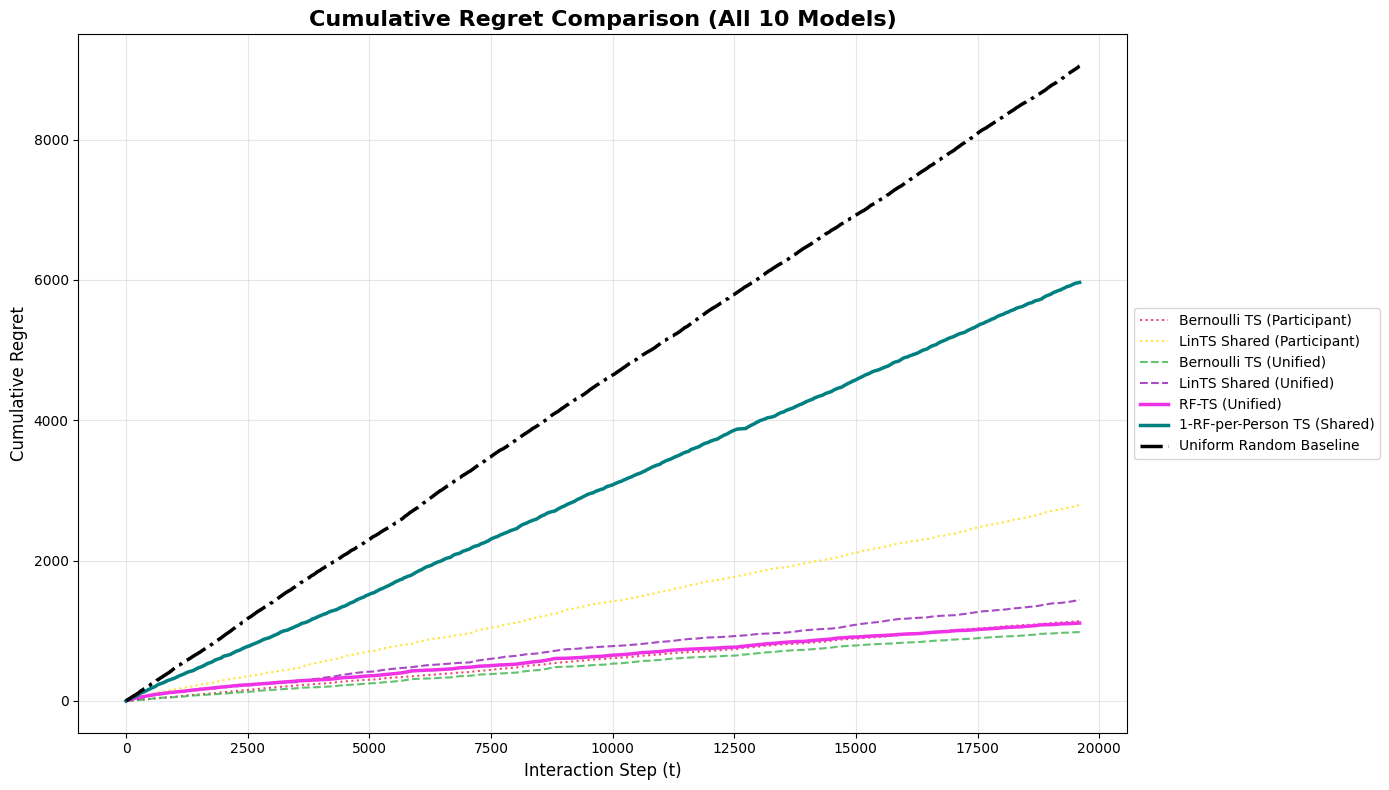

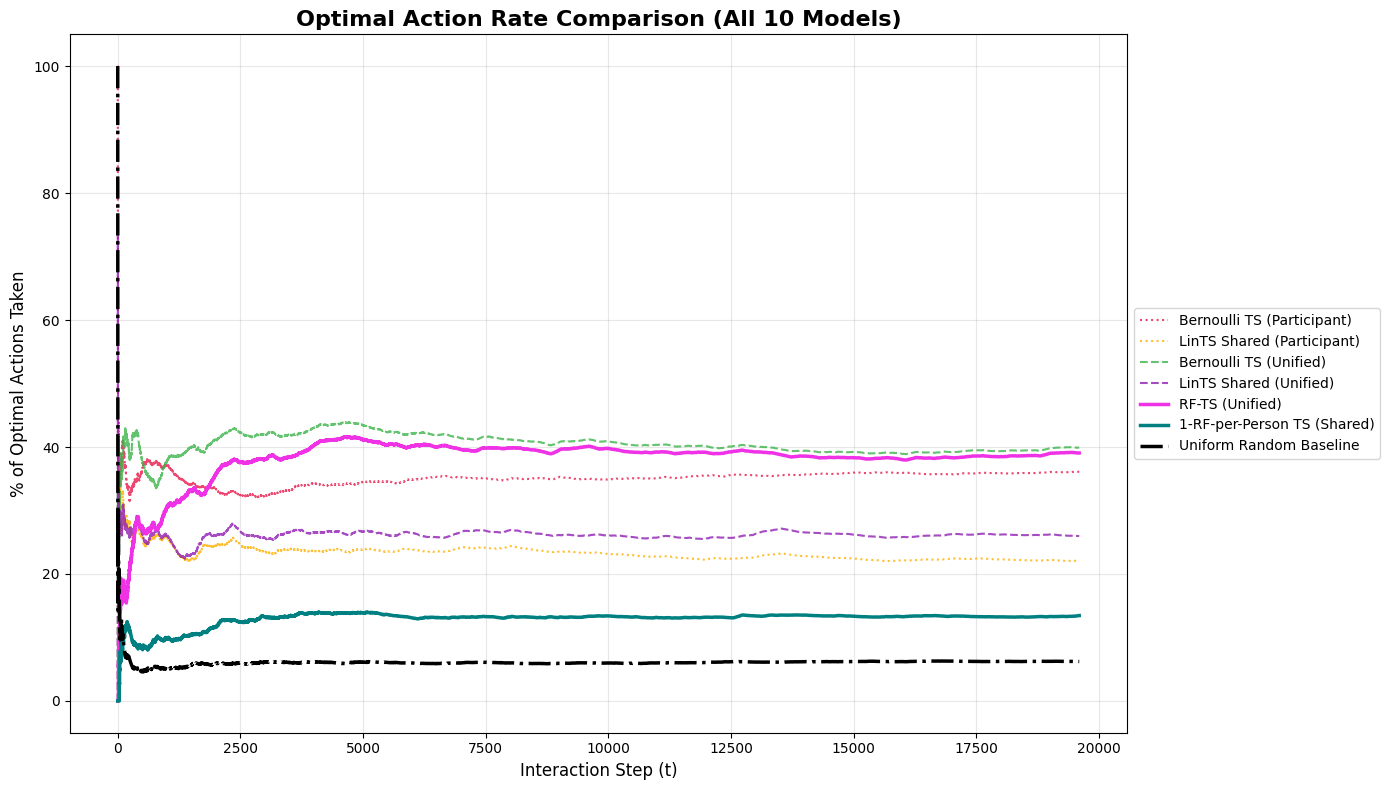

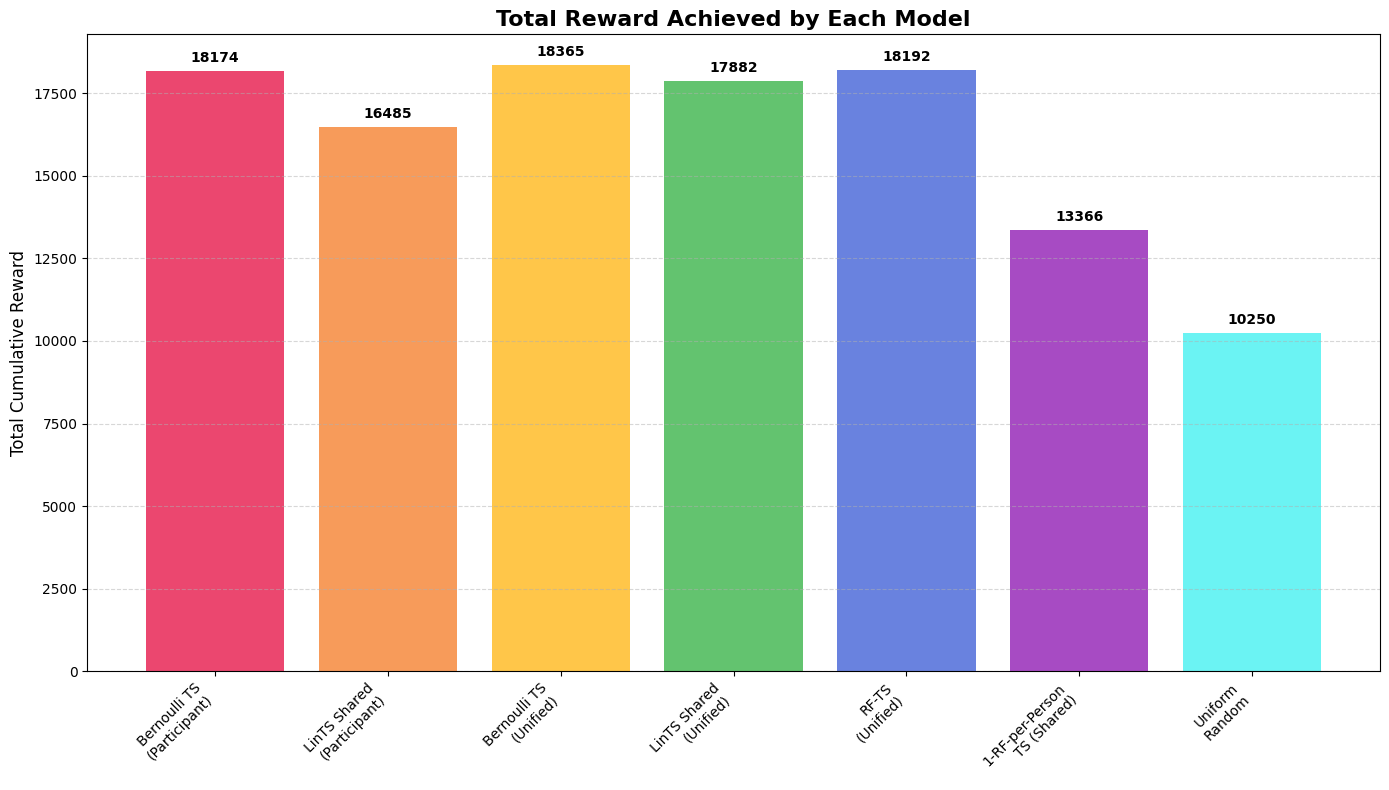

In [40]:
import matplotlib.pyplot as plt

# ==============================================================================
# 1. VARIABLE MAPPING (Read from 4 Models.ipynb & New RF Models)
# ==============================================================================
# -> Map your original notebook's variable names here to avoid NameErrors.
# Replace the right side of the equals sign with your exact variable names.

# --- Original Participant-Level Models ---
orig_bts_p_regret = cumulative_regret_bts 
orig_bts_p_opt    = optimal_action_rate_bts


orig_lints_ps_regret = linTS_Shared_cumulative_regret 
orig_lints_ps_opt    = linTS_Shared_optimal_action_rate

# --- Original Unified/Group Models ---
orig_bts_u_regret = cumulative_regret
orig_bts_u_opt    = optimal_action_rate

orig_lints_us_regret = linTS_Uni_Shared_cumulative_regret
orig_lints_us_opt    = linTS_Uni_Shared_optimal_action_rate

# --- New Random Forest Models ---

rf_ts_u_regret   = rfts_cumulative_regret
rf_ts_u_opt      = rfts_optimal_action_rate

rf_ts_ps_regret  = rf_sp_cumulative_regret
rf_ts_ps_opt     = rf_sp_optimal_action_rate

# --- Random Baseline ---
random_regret    = random_cumulative_regret
random_opt       = random_optimal_action_rate


# --- TOTAL REWARDS (Adjust right-hand side if names differ) ---
orig_bts_p_reward    = total_reward_bts  # Change to your actual variable
orig_lints_ps_reward = linTS_Shared_total_reward

orig_bts_u_reward    = total_reward  
orig_lints_us_reward = linTS_Uni_Shared_total_reward

rf_ts_u_reward       = rfts_total_reward
rf_ts_ps_reward      = rf_sp_total_reward

random_reward        = random_total_reward


# Helper function to convert decimals to percentages
def to_percent(rate_array):
    return [x * 100 for x in rate_array]

# ==============================================================================
# 2. PLOT CUMULATIVE REGRET
# ==============================================================================
plt.figure(figsize=(14, 8))

# Original Participant Models (Dotted)
plt.plot(orig_bts_p_regret, label='Bernoulli TS (Participant)', linestyle=':', color='#e6194B', alpha=0.8) # Red
plt.plot(orig_lints_ps_regret, label='LinTS Shared (Participant)', linestyle=':', color='#ffe119', alpha=0.9) # Yellow

# Original Unified Models (Dashed)
plt.plot(orig_bts_u_regret, label='Bernoulli TS (Unified)', linestyle='--', color='#3cb44b', alpha=0.8) # Green
plt.plot(orig_lints_us_regret, label='LinTS Shared (Unified)', linestyle='--', color='#911eb4', alpha=0.8) # Purple

# New Random Forest Models (Solid, Thick)
plt.plot(rf_ts_u_regret, label='RF-TS (Unified)', linewidth=2.5, color='#f032e6') # Magenta
plt.plot(rf_ts_ps_regret, label='1-RF-per-Person TS (Shared)', linewidth=2.5, color='#008080') # Teal

# Baseline (Dash-Dot, Thick Black)
plt.plot(random_regret, label='Uniform Random Baseline', linestyle='-.', linewidth=2.5, color='#000000') # Black

plt.title('Cumulative Regret Comparison (All 10 Models)', fontsize=16, fontweight='bold')
plt.xlabel('Interaction Step (t)', fontsize=12)
plt.ylabel('Cumulative Regret', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_regret.png')
plt.show()

# ==============================================================================
# 3. PLOT OPTIMAL ACTION RATE
# ==============================================================================
plt.figure(figsize=(14, 8))

# Original Participant Models (Dotted)
plt.plot(to_percent(orig_bts_p_opt), label='Bernoulli TS (Participant)', linestyle=':', color='#e6194B', alpha=0.8)
plt.plot(to_percent(orig_lints_ps_opt), label='LinTS Shared (Participant)', linestyle=':', color='#ffB81c', alpha=0.9) # Darker Yellow for visibility on white bg

# Original Unified Models (Dashed)
plt.plot(to_percent(orig_bts_u_opt), label='Bernoulli TS (Unified)', linestyle='--', color='#3cb44b', alpha=0.8)
plt.plot(to_percent(orig_lints_us_opt), label='LinTS Shared (Unified)', linestyle='--', color='#911eb4', alpha=0.8)

# New Random Forest Models (Solid, Thick)
plt.plot(to_percent(rf_ts_u_opt), label='RF-TS (Unified)', linewidth=2.5, color='#f032e6')
plt.plot(to_percent(rf_ts_ps_opt), label='1-RF-per-Person TS (Shared)', linewidth=2.5, color='#008080')

# Baseline (Dash-Dot, Thick Black)
plt.plot(to_percent(random_opt), label='Uniform Random Baseline', linestyle='-.', linewidth=2.5, color='#000000')

plt.title('Optimal Action Rate Comparison (All 10 Models)', fontsize=16, fontweight='bold')
plt.xlabel('Interaction Step (t)', fontsize=12)
plt.ylabel('% of Optimal Actions Taken', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('optimal_action.png')
plt.show()


# ==============================================================================
# 4. PLOT TOTAL REWARDS (Bar Chart)
# ==============================================================================
plt.figure(figsize=(14, 8))

models = [
    'Bernoulli TS\n(Participant)', 'LinTS Shared\n(Participant)',
    'Bernoulli TS\n(Unified)', 'LinTS Shared\n(Unified)',
    'RF-TS\n(Unified)', '1-RF-per-Person\nTS (Shared)',
    'Uniform\nRandom'
]

rewards = [
    orig_bts_p_reward, orig_lints_ps_reward,
    orig_bts_u_reward, orig_lints_us_reward,
     rf_ts_u_reward, rf_ts_ps_reward,
    random_reward
]

colors = [
    '#e6194B', '#f58231', '#ffB81c', 
    '#3cb44b', '#4363d8', '#911eb4', 
    '#46f0f0', '#f032e6', '#008080', 
    '#000000'
]

bars = plt.bar(models, rewards, color=colors, alpha=0.8)

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(rewards)*0.01), 
             f'{int(yval)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Total Reward Achieved by Each Model', fontsize=16, fontweight='bold')
plt.ylabel('Total Cumulative Reward', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('total_reward.png')
plt.show()

___

## Grid search for no of trees in RF ensemble

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

class RF_TSAgent:
    def __init__(self, n_arms=16, n_activities=10, v=1.0, n_trees=20):
        self.n_arms = n_arms
        self.d = n_activities
        self.v = v  # Variance multiplier for exploration (similar to LinTS)
        
        # Initialize a Random Forest for each arm
        self.models = [RandomForestRegressor(n_estimators=n_trees, random_state=42) for _ in range(n_arms)]
        
        self.history_X = [[] for _ in range(n_arms)]
        self.history_y = [[] for _ in range(n_arms)]
        self.is_fit = [False] * n_arms

    def _get_features(self, activity):
        x = np.zeros(self.d)
        x[activity] = 1.0
        return x.reshape(1, -1) 

    def arm_to_pull(self, activity):
        x_t = self._get_features(activity)
        scores = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # 1. Force exploration if the arm has never been pulled
            if not self.is_fit[arm]:
                # Optimistic initialization: give it a guaranteed high score
                scores[arm] = 1e6 
                continue
            
            # 2. Get predictions from EVERY tree in the forest
            rf = self.models[arm]
            tree_predictions = np.array([tree.predict(x_t)[0] for tree in rf.estimators_])
            
            # 3. Calculate Mean and Standard Deviation across the trees
            mean_reward = np.mean(tree_predictions)
            std_dev = np.std(tree_predictions)
            
            # 4. THE THOMPSON SAMPLING MAGIC
            # Draw a sample from a Gaussian distribution.
            # We add 1e-6 to std_dev to prevent a crash if all trees predict the exact same value (variance = 0)
            scores[arm] = np.random.normal(loc=mean_reward, scale=self.v * (std_dev + 1e-6))
            
        # Return the arm with the highest sampled score
        return np.argmax(scores)

    def update(self, activity, arm, reward):
        x_t = self._get_features(activity)[0] 
        
        self.history_X[arm].append(x_t)
        self.history_y[arm].append(reward)
        
        X_train = np.array(self.history_X[arm])
        y_train = np.array(self.history_y[arm])
        
        self.models[arm].fit(X_train, y_train)
        self.is_fit[arm] = True

In [42]:
import time
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the grid of tree counts to test
# 5 is very fast but might underfit; 50 is slow but highly accurate
tree_grid = [5, 10, 20, 30, 50]

# Dictionaries to store the final metrics for each configuration
grid_search_rewards = {}
grid_search_regrets = {}

print("Starting Grid Search for Optimal Number of Trees...")
print(f"Testing grid: {tree_grid}")
print("-" * 60)

# =========================================================
# 2. THE GRID SEARCH LOOP
# =========================================================
for n_trees in tree_grid:
    print(f"\nTraining RF-TS Agent with n_trees = {n_trees}...")
    start_time = time.time()
    
    # Initialize the agent with the current number of trees
    agent = RF_TSAgent(n_arms=16, n_activities=10, v=1.0, n_trees=n_trees)
    
    total_reward = 0
    current_regret = 0
    
    # Run the simulation (Consider adding .head(5000) to synthetic_df for a faster test)
    for step, row in enumerate(synthetic_df.itertuples()):
        
        person_n = person_to_idx[row.Participant_Id]
        act_n = act_to_idx[row.Context]
        surr_n = surr_to_idx[row.Social_Context]
        
        # Agent only takes activity in this Unified class
        intervention_n = agent.arm_to_pull(act_n)
        
        # Oracle probability
        true_prob = receptiveness_tensor_4d[person_n, surr_n, act_n, intervention_n]
        
        # Binary reward
        reward = 1 if np.random.rand() < true_prob else 0
        total_reward += reward
        
        # Regret tracking
        best_possible_prob = np.max(receptiveness_tensor_4d[person_n, surr_n, act_n, :])
        current_regret += (best_possible_prob - true_prob)
        
        # Update the agent
        agent.update(act_n, intervention_n, reward)
        
        # Optional: Print progress within the loop so you know it hasn't frozen
        if (step + 1) % 1000 == 0:
            print(f"   [step {step + 1}] ...working...")
            
    elapsed_time = time.time() - start_time
    
    # Store the final results for this configuration
    grid_search_rewards[n_trees] = total_reward
    grid_search_regrets[n_trees] = current_regret
    
    print(f"-> Finished in {elapsed_time:.1f}s | Total Reward: {total_reward} | Final Regret: {current_regret:.2f}")

print("-" * 60)
print("Grid Search Complete!")


# =========================================================
# 3. PLOT THE RESULTS
# =========================================================
trees = list(grid_search_rewards.keys())
rewards = list(grid_search_rewards.values())
regrets = list(grid_search_regrets.values())

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Total Reward on primary Y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Trees (n_trees)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Cumulative Reward', color=color, fontsize=12, fontweight='bold')
ax1.plot(trees, rewards, marker='o', markersize=8, color=color, linewidth=2, label='Total Reward')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a secondary Y-axis for Cumulative Regret
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Total Cumulative Regret', color=color, fontsize=12, fontweight='bold')
ax2.plot(trees, regrets, marker='s', markersize=8, color=color, linewidth=2, linestyle='dashed', label='Cumulative Regret')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Grid Search: Optimal Number of Trees for RF-TS Agent', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.xticks(trees) # Ensure all grid values show on x-axis
plt.show()

# Find and print the best configuration mathematically
best_n_trees = trees[np.argmax(rewards)]
print(f"\nOPTIMAL CONFIGURATION: n_trees = {best_n_trees} (Yielded max reward of {max(rewards)})")

Starting Grid Search for Optimal Number of Trees...
Testing grid: [5, 10, 20, 30, 50]
------------------------------------------------------------

Training RF-TS Agent with n_trees = 5...
   [step 1000] ...working...
   [step 2000] ...working...
   [step 3000] ...working...
   [step 4000] ...working...
   [step 5000] ...working...
   [step 6000] ...working...
   [step 7000] ...working...
   [step 8000] ...working...
   [step 9000] ...working...
   [step 10000] ...working...
   [step 11000] ...working...
   [step 12000] ...working...
   [step 13000] ...working...
   [step 14000] ...working...
   [step 15000] ...working...
   [step 16000] ...working...
   [step 17000] ...working...
   [step 18000] ...working...
   [step 19000] ...working...
-> Finished in 440.0s | Total Reward: 17988 | Final Regret: 1358.74

Training RF-TS Agent with n_trees = 10...
   [step 1000] ...working...
   [step 2000] ...working...
   [step 3000] ...working...
   [step 4000] ...working...
   [step 5000] ...worki

KeyboardInterrupt: 

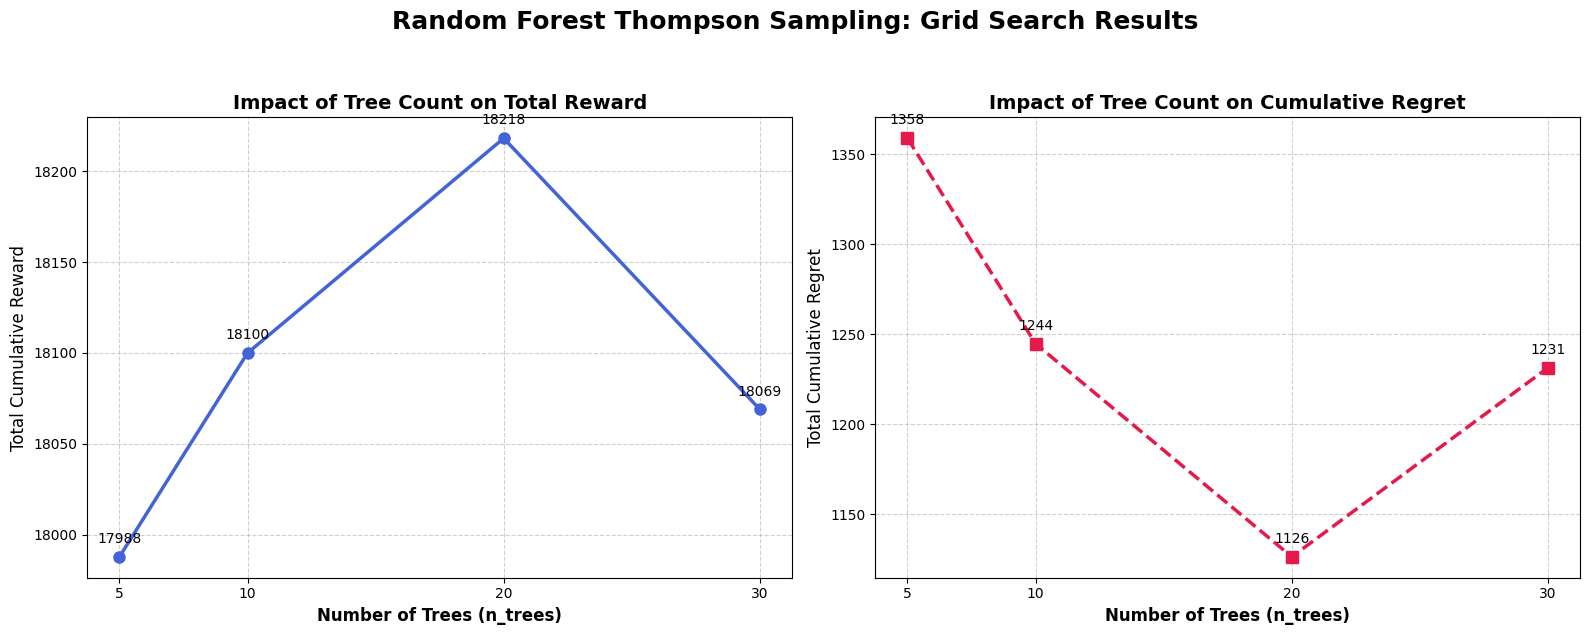

: 

In [ ]:
import matplotlib.pyplot as plt

# =========================================================
# PLOT GRID SEARCH METRICS (Reward & Regret Side-by-Side)
# =========================================================

# Extract the data from the dictionaries populated by the grid search loop
trees = list(grid_search_rewards.keys())
rewards = list(grid_search_rewards.values())
regrets = list(grid_search_regrets.values())

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Total Reward vs. Number of Trees ---
ax1.plot(trees, rewards, marker='o', markersize=8, color='#4363d8', linewidth=2.5) # Blue
ax1.set_title('Impact of Tree Count on Total Reward', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Trees (n_trees)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Cumulative Reward', fontsize=12)
ax1.set_xticks(trees) # Ensure every tree grid value is a tick mark
ax1.grid(True, linestyle='--', alpha=0.6)

# Annotate exact values slightly above the data points
for i, txt in enumerate(rewards):
    ax1.annotate(f'{int(txt)}', (trees[i], rewards[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

# --- Chart 2: Cumulative Regret vs. Number of Trees ---
ax2.plot(trees, regrets, marker='s', markersize=8, color='#e6194B', linewidth=2.5, linestyle='--') # Red
ax2.set_title('Impact of Tree Count on Cumulative Regret', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Trees (n_trees)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Cumulative Regret', fontsize=12)
ax2.set_xticks(trees)
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate exact values slightly above the data points
for i, txt in enumerate(regrets):
    ax2.annotate(f'{int(txt)}', (trees[i], regrets[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

# Add a super title for the whole graphic
fig.suptitle('Random Forest Thompson Sampling: Grid Search Results', fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('rf_grid_search_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

___